# Analisis de los resultados

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm

In [28]:
df = pd.read_csv('../data/dataset.csv')

## Test de hipotesis

No buscamos estudiar *Las medianas son distintas?*, buscamos responder la pregunta **Esta diferencia es real? O es puro ruido de la muestra?**

Proponemos el siguiente test:
- $H_0$: la mediana de reviews_ratio es IGUAL entre juegos caros y baratos. No hay diferencia real entre la relacion precio/reviews
- $H_1$: la mediana de juegos caros es MENOR (direccional). Si existe diferencia, y los caros tienden a tener peores reviews

Entonces, si obtenemos un p-value $< 0.05$, quiere decir que bajo las condiciones de $H_0$ es extremadamente improbable que $H_1$ sea cierto, por lo que rechazamos que $H_0$ sea verdad

En cambio si p-value es mayor, no tenemos evidencia significativa para rechazar $H_0$

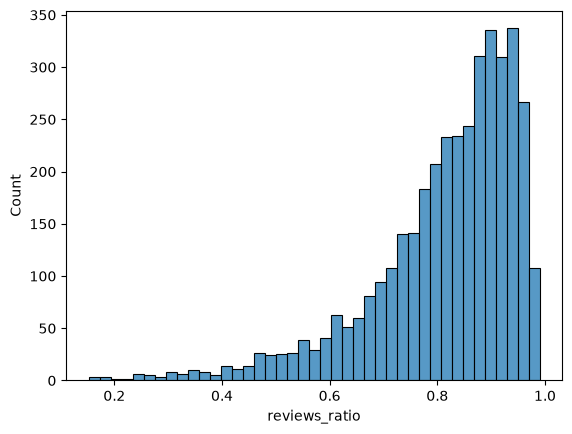

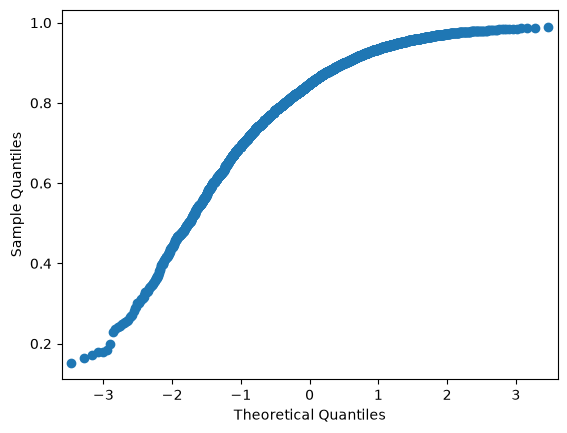

In [29]:
# histograma o qq de reviews_ratio
sns.histplot(df['reviews_ratio'])
sm.qqplot(df['reviews_ratio'])
plt.show()

### Mann-Whitney U

Por que lo elegimos? Por que no elegimos un t-test?

Mann-Whitney U test es un test de estadistica no parametrica para la hipotesis nula que selecciona aleatoriamente valores de $X$ y $Y$ de dos poblaciones que tienen la misma distribucion, las cuales no son normales. Mann-Whitney compara 'estocasticamente mayor/menor' sin asumir distribucion

El valor de $U$ calculado por el test puede ser convertido a una medida del tamaño del efecto al dividirlo por el maximo valor de $U$

El test asume ciertas condiciones: 
- Ambas grupos de observaciones son independientes de la otra
- Las respuestas son continuas y ordinales (se puede decir cual es mayor, por ejemplo)
- Bajo $H_0$ ambas distribuciones son identicas, pero diferentes de la normal: `reviews_ratio` esta acotado entre $[0,1]$ y sesgado (izquierda)
- La hipotesis alternativa $H_1$ es que las distribuciones no son identicas

Elegimos este test en vez del t-student test, porque justamente nuestros datos no tienen distribucion normal y estamos comparando medianas en vez de medias (que en realidad, no compara la mediana directamente, sino la dominancia estocastica)

**Intuitivamente**, es como comparar todos los juegos al azar de ambos grupos, y responder:
- En cuantos pares el caro tiene mejor ratio?
- En cuantos el barato?

Uno esperaria que sea 50/50. Pero si es diferente, ese resultado es la base del estadistico $U$

Al realizar el test, nos da un p-value $= 9.45e-10$. Basicamente, el efecto **existe**.

Cabe aclarar, que usamos el atributo `alternative='loss'` para realizar el test en solo 1 cola. Especificamente respondemos a la pregunta 'los caros son especificamente PEORES?', de manera direccional (en la realidad, cambia que un p-value es la mitad del otro)

In [32]:
cara = df[df["bucket"] == "50+"]["reviews_ratio"]
dulce = df[df["bucket"] == "10-20"]["reviews_ratio"]
print(stats.mannwhitneyu(cara, dulce, alternative="less"))   # p < 0.05 = la diferencia es real

MannwhitneyuResult(statistic=np.float64(121917.5), pvalue=np.float64(9.450991953535856e-10))


Aunque, que el efecto exista no quiere decir que sea significativo. Vamos a medir que tanto peso tiene en los datos, calculando el *Cliff's delta*

Que sale de
- Cliff's delta = (% de pares donde gana el barato) − (% de pares donde gana el caro)

Con n grande, cualquier diferencia da p chico. El p-value mide "existe?", el tamaño de efecto mide "cuanto?" y reporta AMBOS.

En este caso, el valor de Cliff's delta es de -0.242, el cual es pequeño pero si causa un efecto real 

Finalmente realizamos boostrap con un intervalo de confianza para verificar que la diferencia de medias existe y es lo suficientemente significativa. Lo que hace *boostrap* es remuestrar aleatoriamente los datos para estimar la incertidumbre. Se hace esto n veces (muchas) y calculamos la diferencia de medianas en todas y cada una de las iteraciones, luego resulta que el 95% de los casos cayeron entre -0.077 y -0.031, lo cual no cruza por 0 y nos demuestra que si existe esa diferencia

In [ ]:
import numpy as np

cara  = df[df["bucket"] == "50+"]["reviews_ratio"]
dulce = df[df["bucket"] == "10-20"]["reviews_ratio"]

u, p = stats.mannwhitneyu(cara, dulce, alternative="less")
print(f"n caro={len(cara)}, n dulce={len(dulce)}")
print(f"medianas: caro={cara.median():.3f} vs dulce={dulce.median():.3f}")
print(f"U={u:.0f}, p={p:.2e}")

def cliffs_delta(x, y):
    n = len(x) * len(y)
    d = (sum(1 for xi in x for yi in y if xi > yi) -
         sum(1 for xi in x for yi in y if xi < yi)) / n
    return d

print(f"Cliff's delta: {cliffs_delta(cara, dulce):.3f}")
# interpretacipn: <0.147 despreciable | <0.33 pequeño | <0.474 mediano | >= grande

# IC bootstrap de la diferencia de medianas
rng = np.random.default_rng(42)
diffs = [np.median(rng.choice(cara, len(cara), replace=True)) -
         np.median(rng.choice(dulce, len(dulce), replace=True))
         for _ in range(2000)]
ci = np.percentile(diffs, [2.5, 97.5])
print(f"Diferencia de medianas (caro − dulce): {np.median(cara)-np.median(dulce):.3f}")
print(f"IC 95% bootstrap: [{ci[0]:.3f}, {ci[1]:.3f}]")  # no cruza 0 = sólido


n caro=243, n dulce=1324
medianas: caro=0.811 vs dulce=0.868
U=121918, p=9.45e-10
Cliff's delta: -0.242
Diferencia de medianas (caro − dulce): -0.058
IC 95% bootstrap: [-0.077, -0.031]


## Conclusiones

Despues de realizar la extaccion de datos de las APIs de Steam, un analisis exploratorio de datos, y finalmente un test de hipotesis con varios otros test para corroborar la existencia y importancia de esta diferencia, llegamos a las siguientes conclusiones

### Existe diferencia?

Si, existe. Lo demostramos con el p-value de $9e-10$

### Cuanto importa?

Poco realmente, el Cliff's delta value nos dio -0.24

### Cuanto diferencia en concreto?

Obtuvimos ~5.8 puntos de mediana (81.1% vs 86.8%)

### Con que tener cuidado?
Basicamente, es cierto que existe y tiene efecto bajo, pero no podemos afirmar que el precio cause las reviews malas, ni que todo juego caro es malo

Debemos evitar confundir correlacion con causalidad, puede existir este efecto, pero no deberse directamente al precio

Mas alla de que es algo con poco efecto en la practica, ya que hay parametros mucho mas importantes que se consideran dentro de la industria del videojuego.